In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models

2026-04-25 18:04:06.107617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777140246.314221      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777140246.366244      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777140246.813236      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777140246.813274      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777140246.813277      55 computation_placer.cc:177] computation placer alr

In [2]:
train_dir = '/kaggle/input/datasets/tejpaviraj/arecanut/Arecanut_dataset/Arecanut_dataset/train'
val_dir = '/kaggle/input/datasets/tejpaviraj/arecanut/Arecanut_dataset/Arecanut_dataset/test'
test_dir = '/kaggle/input/datasets/tejpaviraj/arecanut/final_testing-20230830T042904Z-001/final_testing'
img_size = (224,224)
batch_size = 32 

train_ds_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed = 42,
    shuffle = True, 
    image_size = img_size,
    batch_size = batch_size
)

val_ds_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    seed = 42,
    shuffle = True, 
    image_size = img_size,
    batch_size = batch_size
)

test_ds_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed = 42,
    shuffle = True, 
    image_size = img_size,
    batch_size = batch_size
)

Found 8847 files belonging to 9 classes.


I0000 00:00:1777140276.921275      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2216 files belonging to 9 classes.
Found 1118 files belonging to 6 classes.


In [3]:
print('dataset size')
print(f'Train data size: {len(train_ds_data)}')
print(f'Val data size: {len(val_ds_data)}')

dataset size
Train data size: 277
Val data size: 70


In [4]:
print('dataset class names :\n')
display(train_ds_data.class_names)

dataset class names :



['Healthy_Leaf',
 'Healthy_Nut',
 'Healthy_Trunk',
 'Mahali_Koleroga',
 'Stem_bleeding',
 'bud borer',
 'healthy_foot',
 'stem cracking',
 'yellow leaf disease']

In [5]:
for image_batch, label_batch in train_ds_data.take(1):
    print(image_batch.shape)
    print(label_batch.shape)

(32, 224, 224, 3)
(32,)


In [6]:
from collections import Counter

class_names = train_ds_data.class_names
label_counter = Counter()

for images, labels in train_ds_data:
    label_counter.update(labels.numpy())

# print result
for label, count in label_counter.items():
    print(f"{class_names[label]}: {count}")

stem cracking: 540
Healthy_Trunk: 1432
Mahali_Koleroga: 2563
yellow leaf disease: 1477
Healthy_Leaf: 604
Healthy_Nut: 1886
bud borer: 144
healthy_foot: 50
Stem_bleeding: 151


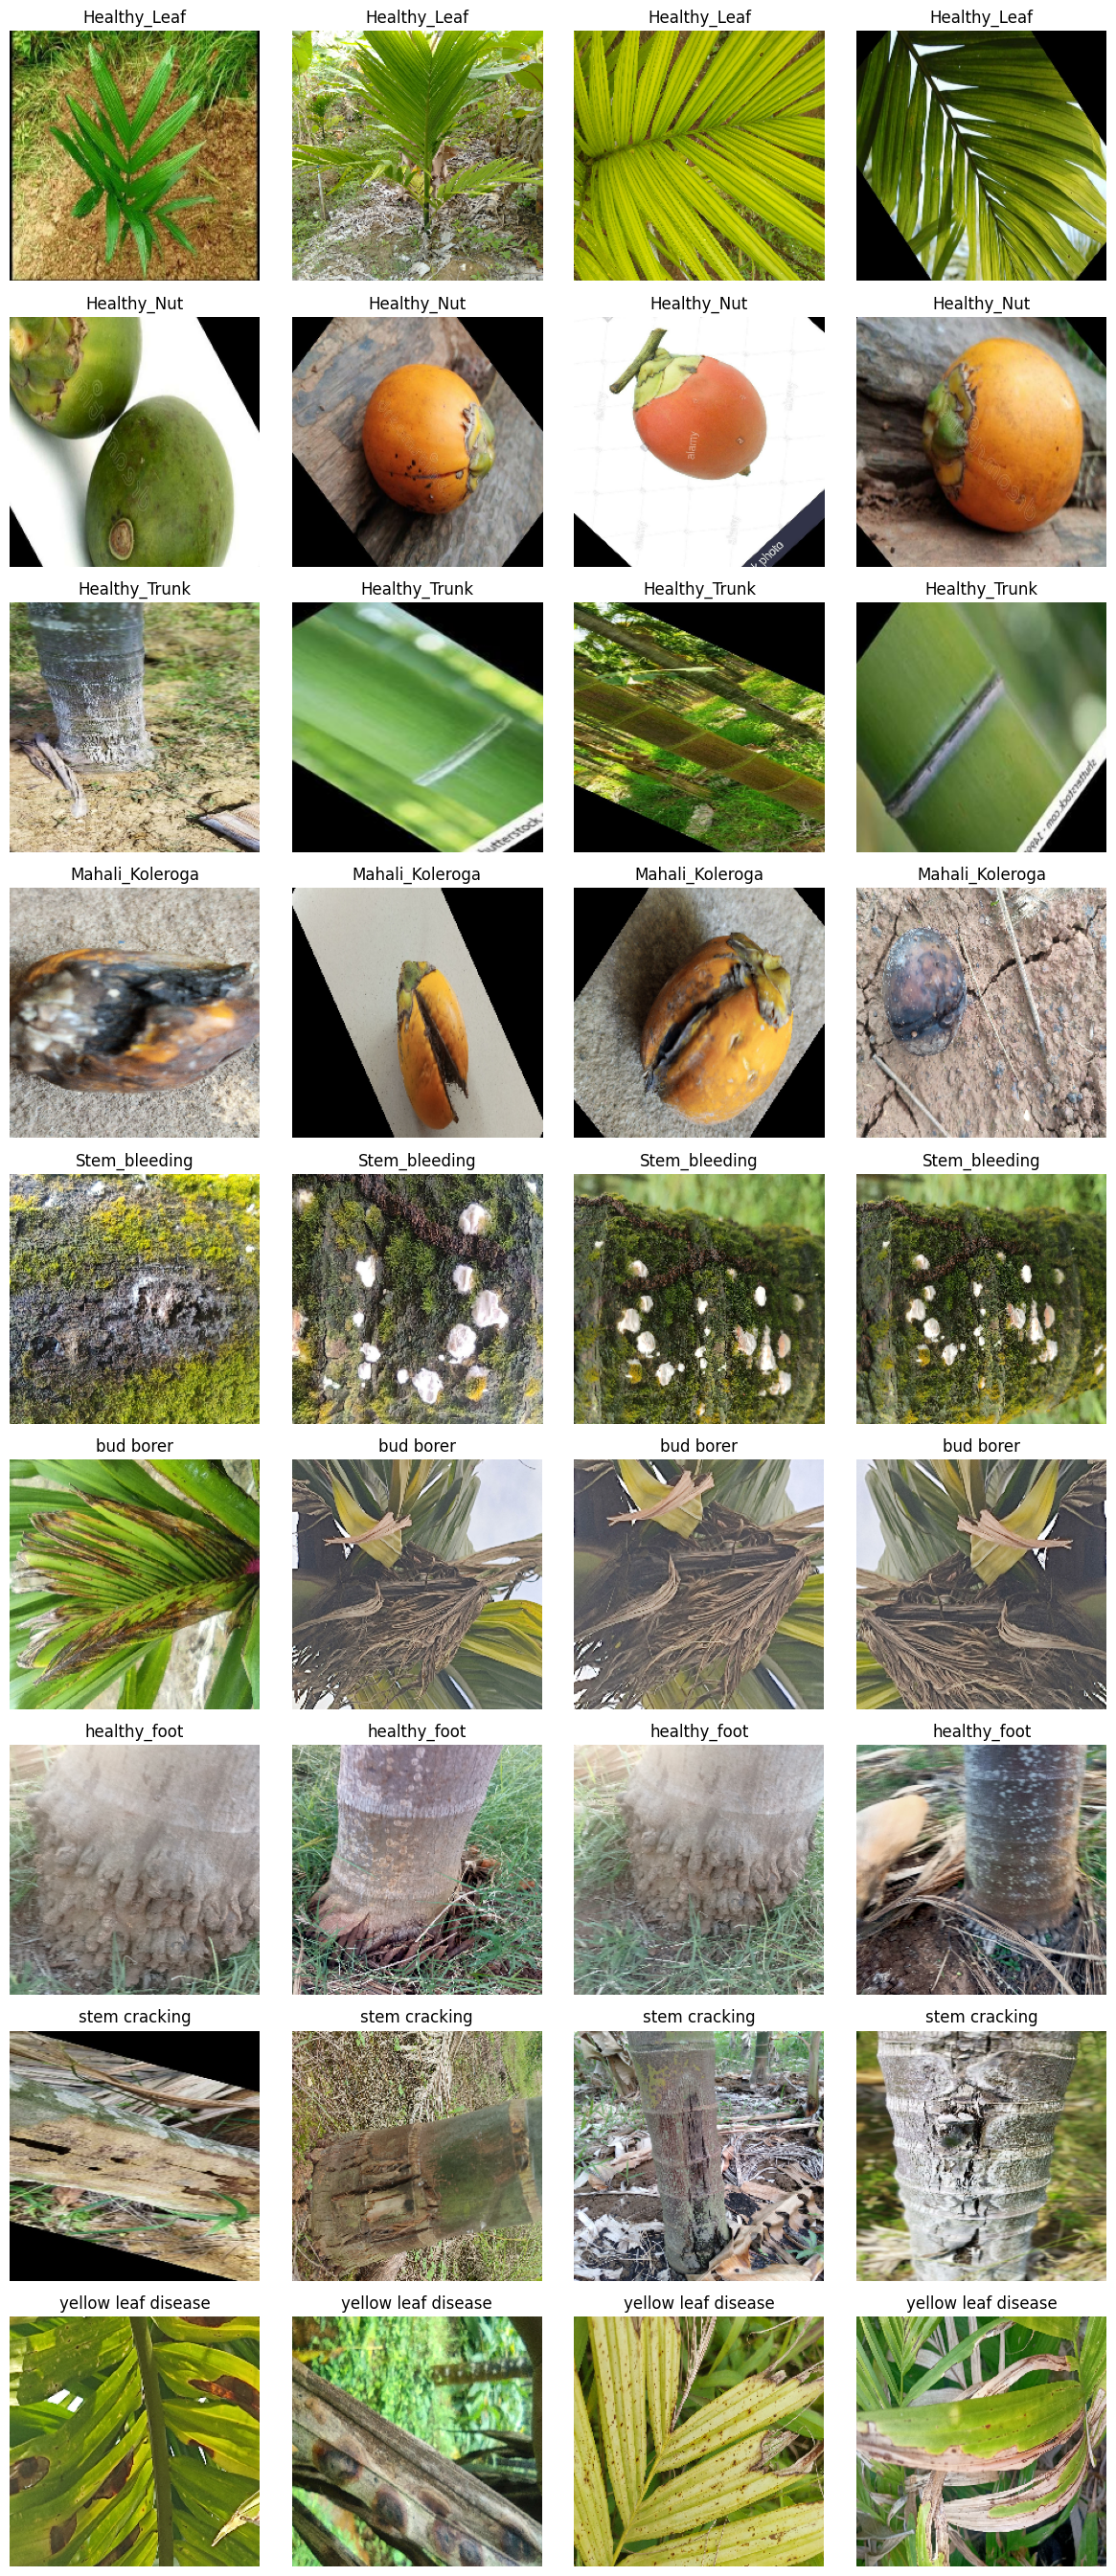

In [7]:
class_names = train_ds_data.class_names


class_images = {i: [] for i in range(len(class_names))}


for images, labels in train_ds_data:
    for i in range(len(labels)):
        label = labels[i].numpy()
        
        if len(class_images[label]) < 4:   
            class_images[label].append(images[i].numpy())
    

    if all(len(v) >= 4 for v in class_images.values()):
        break


plt.figure(figsize=(12, len(class_names)*3))

plot_index = 1
for class_idx, imgs in class_images.items():
    for img in imgs:
        plt.subplot(len(class_names), 4, plot_index)
        plt.imshow(img.astype("uint8"))
        plt.title(class_names[class_idx])
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for _, y in train_ds_data:
    labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

In [9]:
class_names = train_ds_data.class_names

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_data.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_data.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
    ]
)

In [12]:
base_model = tf.keras.applications.ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    base_model, 

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    # layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [33]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,171,017 (92.21 MB)

 Trainable params: 579,209 (2.21 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [34]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    callbacks = callbacks,
    # class_weight = class_weights
)

Epoch 1/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.3520 - loss: 1.7054 - val_accuracy: 0.4959 - val_loss: 1.5394 - learning_rate: 1.0000e-04
Epoch 2/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/step - accuracy: 0.5649 - loss: 1.1660 - val_accuracy: 0.6444 - val_loss: 1.0454 - learning_rate: 1.0000e-04
Epoch 3/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/step - accuracy: 0.6402 - loss: 0.9922 - val_accuracy: 0.6877 - val_loss: 0.8746 - learning_rate: 1.0000e-04
Epoch 4/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/step - accuracy: 0.6718 - loss: 0.8976 - val_accuracy: 0.7125 - val_loss: 0.8102 - learning_rate: 1.0000e-04
Epoch 5/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/step - accuracy: 0.7102 - loss: 0.7979 - val_accuracy: 0.7473 - val_loss: 0.7319 - learning_rate: 1.0000e-04
Epoch 6/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/step - accuracy: 0.7357 - loss: 0.7558 - val_accuracy: 0.7581 - val_loss: 0.7049 - learning_rate: 1.0000e-04
Epoch 7/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/st

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

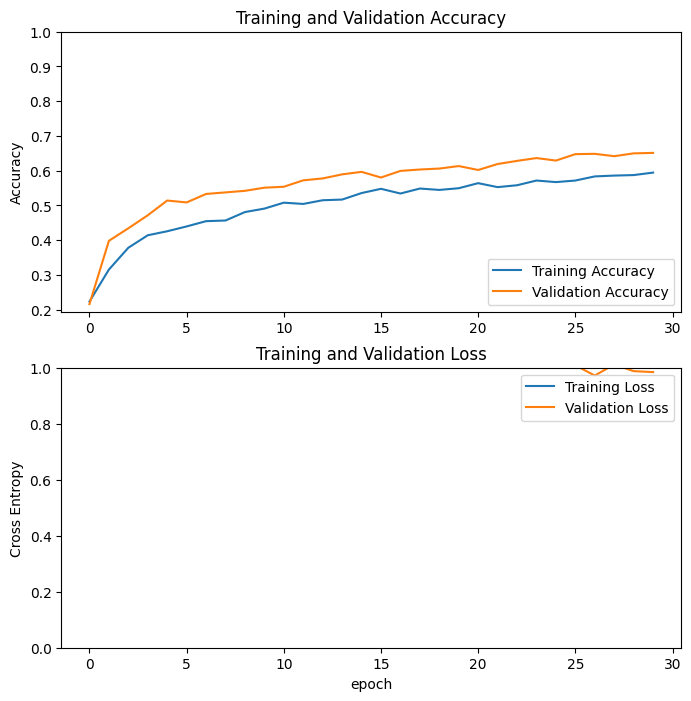

In [20]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [46]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    callbacks = callbacks,
    # class_weight = class_weights
)

Epoch 1/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 49s 131ms/step - accuracy: 0.4341 - loss: 1.6383 - val_accuracy: 0.6119 - val_loss: 1.2779 - learning_rate: 1.0000e-05
Epoch 2/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.6518 - loss: 0.9985 - val_accuracy: 0.6958 - val_loss: 0.8559 - learning_rate: 1.0000e-05
Epoch 3/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.7498 - loss: 0.7687 - val_accuracy: 0.7658 - val_loss: 0.6621 - learning_rate: 1.0000e-05
Epoch 4/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.7662 - loss: 0.6767 - val_accuracy: 0.7825 - val_loss: 0.6013 - learning_rate: 1.0000e-05
Epoch 5/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.7933 - loss: 0.5970 - val_accuracy: 0.8118 - val_loss: 0.5521 - learning_rate: 1.0000e-05
Epoch 6/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - accuracy: 0.8121 - loss: 0.5457 - val_accuracy: 0.8353 - val_loss: 0.4849 - learning_rate: 1.0000e-05
Epoch 7/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 34s 12

In [47]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

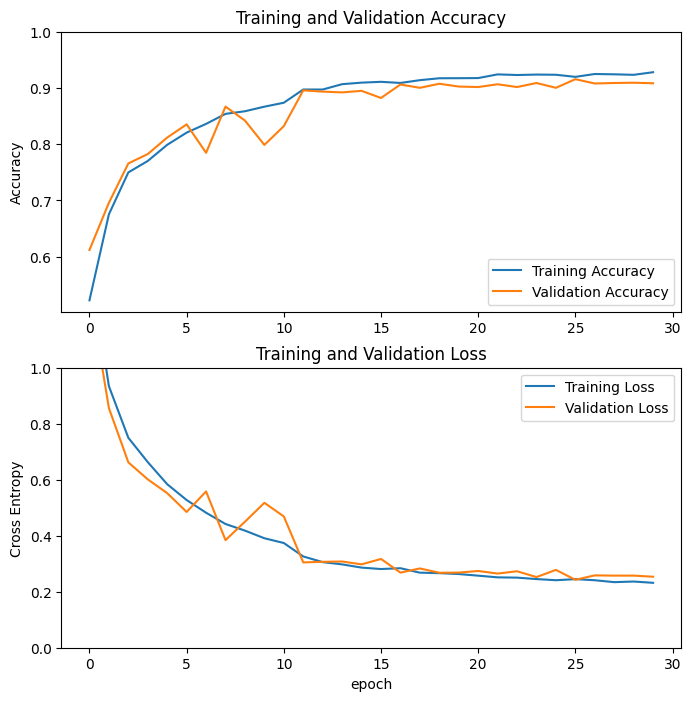

In [48]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [49]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9219 - loss: 0.2399
Validation Accuracy: 0.9156137108802795


In [42]:
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [43]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,641 (6.19 MB)

 Trainable params: 1,619,721 (6.18 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [44]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    callbacks = callbacks,
    # class_weight = class_weights
)

Epoch 1/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 49s 160ms/step - accuracy: 0.4253 - loss: 1.6486 - val_accuracy: 0.3082 - val_loss: 1.8440 - learning_rate: 1.0000e-05
Epoch 2/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.6313 - loss: 1.1062 - val_accuracy: 0.6701 - val_loss: 0.9067 - learning_rate: 1.0000e-05
Epoch 3/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.6494 - loss: 0.9925 - val_accuracy: 0.7455 - val_loss: 0.7646 - learning_rate: 1.0000e-05
Epoch 4/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.6887 - loss: 0.9115 - val_accuracy: 0.7035 - val_loss: 0.8685 - learning_rate: 1.0000e-05
Epoch 5/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.7055 - loss: 0.8551 - val_accuracy: 0.7473 - val_loss: 0.7545 - learning_rate: 1.0000e-05
Epoch 6/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.7164 - loss: 0.8299 - val_accuracy: 0.7536 - val_loss: 0.7480 - learning_rate: 1.0000e-05
Epoch 7/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 43s 15

In [ ]:
model.save("arecanut_resnet_model.h5")